In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import numpy as np
import pandas as pd

## EDA

## Image count of each category

In [26]:
base_path = "../AI_Real_Dataset"

for dataset_type in ["Ai_generated_dataset", "real_dataset"]:
    print(f"\n{dataset_type}")
    for category in os.listdir(os.path.join(base_path, dataset_type)):
        if category != '.DS_Store':
            path = os.path.join(base_path, dataset_type, category)
            print(category, len(os.listdir(path)))


Ai_generated_dataset
city 50
nature 50
animals 50
people 50
food 50

real_dataset
city 150
nature 150
animals 148
people 147
food 150


## Show sample images AI vs Real

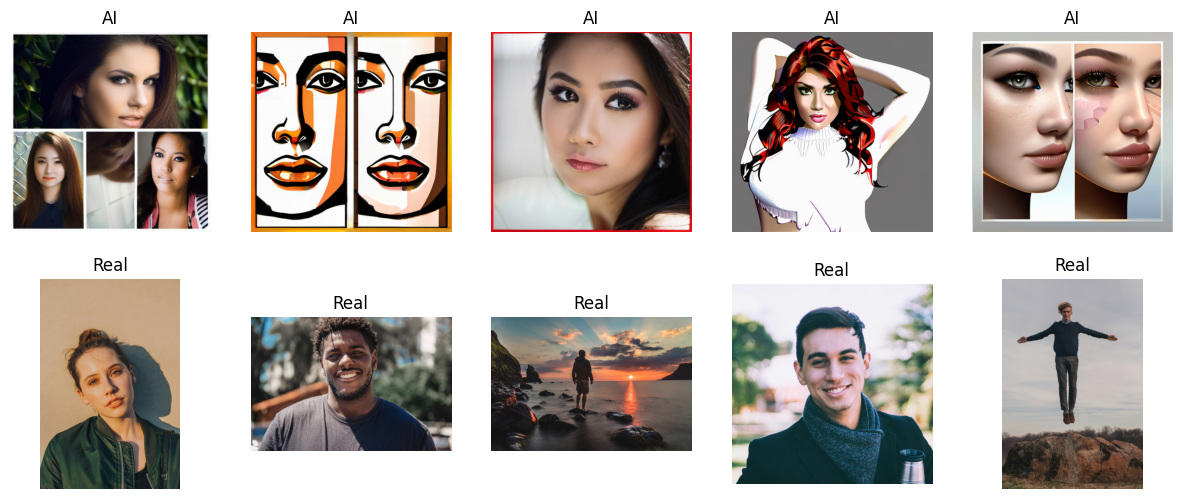

In [6]:
def show_samples(category, n=5):
    fig, axes = plt.subplots(2, n, figsize=(15,6))
    
    for i in range(n):
        ai_path = f"../AI_Real_Dataset/Ai_generated_dataset/{category}"
        real_path = f"../AI_Real_Dataset/real_dataset/{category}"
        
        ai_img = Image.open(os.path.join(ai_path, random.choice(os.listdir(ai_path))))
        real_img = Image.open(os.path.join(real_path, random.choice(os.listdir(real_path))))
        
        axes[0, i].imshow(ai_img)
        axes[0, i].set_title("AI")
        axes[0, i].axis("off")
        
        axes[1, i].imshow(real_img)
        axes[1, i].set_title("Real")
        axes[1, i].axis("off")
        
    plt.show()

show_samples("people")

## Image Sizes
- cnn expect same sizes

AI: 250 images
Real: 745 images


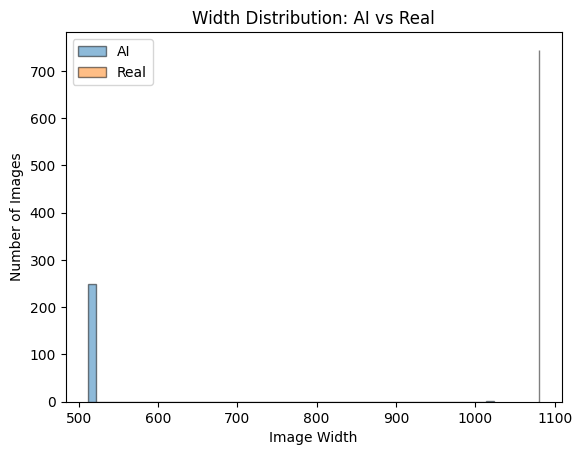

AI: 250 images
Real: 745 images


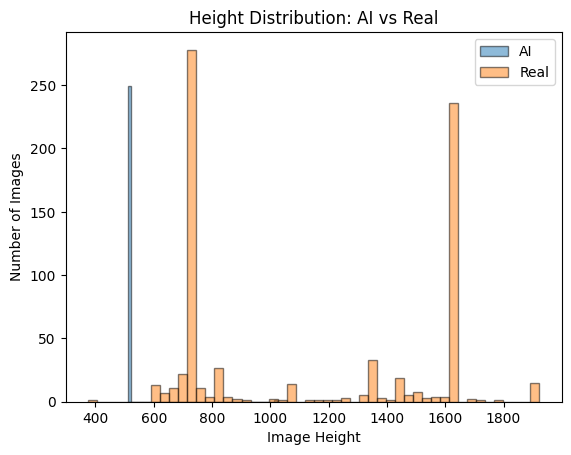

In [36]:
records = []

for dataset_type in ["Ai_generated_dataset", "real_dataset"]:
    label = "AI" if dataset_type == "Ai_generated_dataset" else "Real"
    
    for category in os.listdir(os.path.join(base_path, dataset_type)):
        if category != '.DS_Store':
            category_path = os.path.join(base_path, dataset_type, category)
            
            for file in os.listdir(category_path):
                file_path = os.path.join(category_path, file)
                
                try:
                    img = Image.open(file_path)
                    width, height = img.size
                    
                    records.append({
                        "label": label,
                        "category": category,
                        "width": width,
                        "height": height,
                        "aspect_ratio": width / height
                    })
                except:
                    pass

size_df = pd.DataFrame(records)
size_df.head(20)

# plot width ai vs real
for label in ["AI", "Real"]:
    subset = size_df[size_df["label"] == label]
    print(f"{label}: {len(subset)} images")
    plt.hist(subset["width"], bins=50, alpha=0.5, label=label, edgecolor='black')

plt.xlabel("Image Width")
plt.ylabel("Number of Images")
plt.title("Width Distribution: AI vs Real")
plt.legend()
plt.show()

# plot height ai vs real
for label in ["AI", "Real"]:
    subset = size_df[size_df["label"] == label]
    print(f"{label}: {len(subset)} images")
    plt.hist(subset["height"], bins=50, alpha=0.5, label=label, edgecolor='black')

plt.xlabel("Image Height")
plt.ylabel("Number of Images")
plt.title("Height Distribution: AI vs Real")
plt.legend()
plt.show()

AI images tend to have 512 x 512 dimensions; likely generated that way 

Implication: cannot generalize for resized images, different datasets

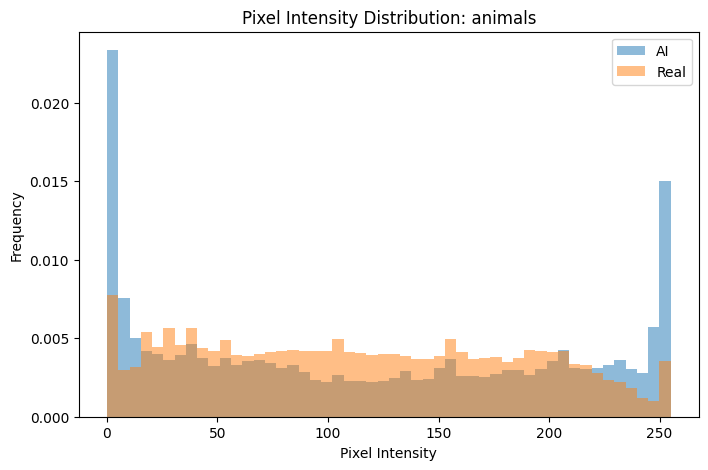

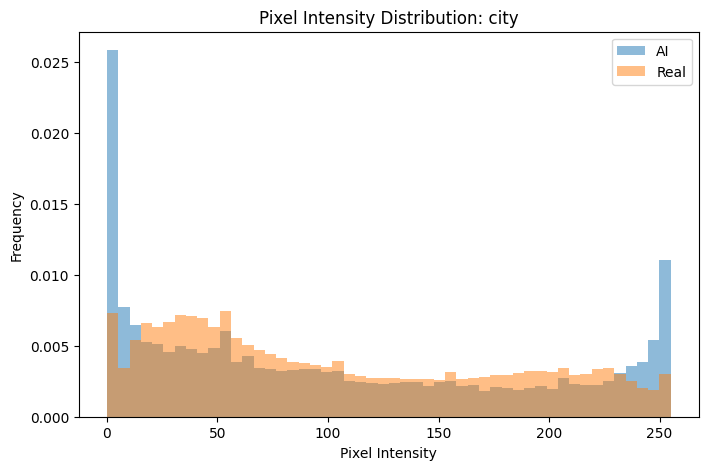

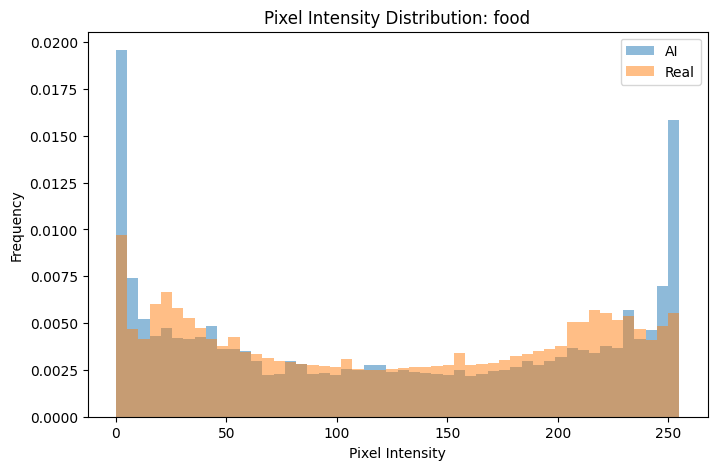

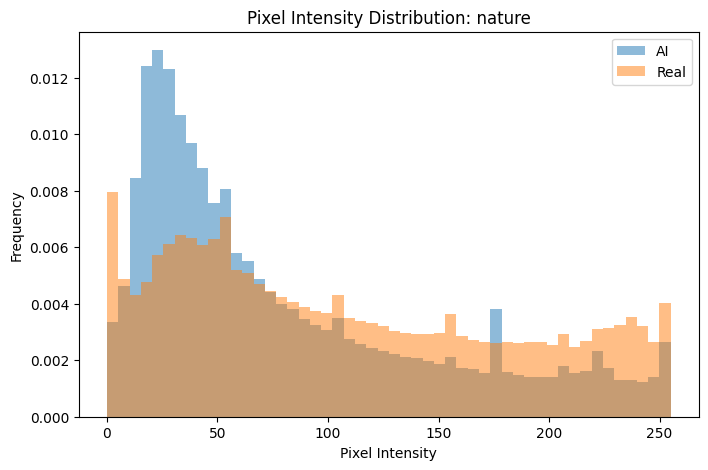

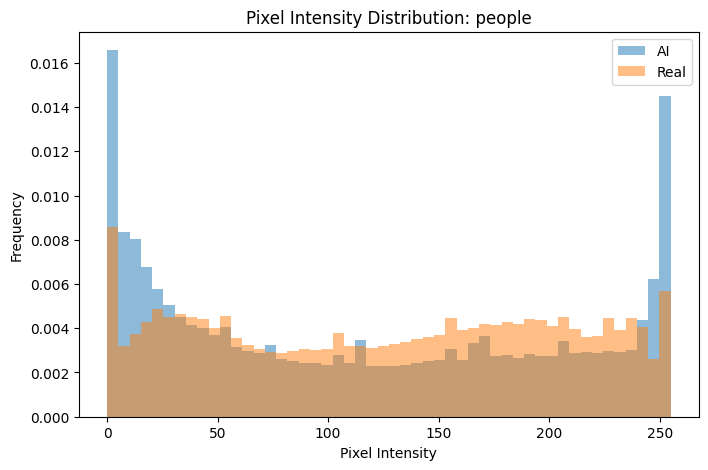

In [13]:
import numpy as np

categories = ["animals", "city", "food", "nature", "people"]

def collect_pixels(folder, max_images=100):
    pixels = []
    
    files = os.listdir(folder)[:max_images]
    
    for file in files:
        file_path = os.path.join(folder, file)
        
        try:
            img = Image.open(file_path).convert("RGB")
            img = img.resize((224, 224))
            arr = np.array(img)
            pixels.extend(arr.flatten())
        except:
            pass
    
    return np.array(pixels)

for category in categories:
    ai_folder = os.path.join(base_path, "Ai_generated_dataset", category)
    real_folder = os.path.join(base_path, "real_dataset", category)
    
    ai_pixels = collect_pixels(ai_folder)
    real_pixels = collect_pixels(real_folder)
    
    plt.figure(figsize=(8, 5))
    plt.hist(ai_pixels, bins=50, alpha=0.5, label="AI", density=True)
    plt.hist(real_pixels, bins=50, alpha=0.5, label="Real", density=True)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.title(f"Pixel Intensity Distribution: {category}")
    plt.legend()
    plt.show()

- animals and people tend to have broad and ~uniform distribution across mid range intensities
    - ai images show spikes at extremes
- city and nature tend to have more dark pixels
    - maybe due building shadows and dark trees/vegetation?
    - ai images have more dark pixels
- food has high pixel intensity for both low and high pixel intensities
    - ai images emphasize the low and high pixel intensities more than the real images

overall, the real images have more uniform distribution across mid range intensities; less extreme intensities than ai images. 

## Edge/Texture

In [ ]:
import cv2

def edge_strength(folder, max_images=100):
    strengths = []
    
    for file in os.listdir(folder)[:max_images]:
        path = os.path.join(folder, file)
        try:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            edges = cv2.Canny(img, 100, 200)
            strengths.append(edges.mean())
        except:
            pass
    
    return np.mean(strengths)

categories = ["animals", "city", "food", "nature", "people"]

for category in categories:
    ai_folder = os.path.join(base_path, "Ai_generated_dataset", category)
    real_folder = os.path.join(base_path, "real_dataset", category)

    print(f"AI {category}:", edge_strength(ai_folder))
    print(f"Real {category}:", edge_strength(real_folder))
    print ('-----------------')

AI animals: 19.899326705932616
Real animals: 14.35030424171297
-----------------
AI city: 20.29607162475586
Real city: 24.521256727606055
-----------------
AI food: 20.013143062591553
Real food: 14.762556975047811
-----------------
AI nature: 13.893153762817382
Real nature: 20.57395832899364
-----------------
AI people: 14.960355377197265
Real people: 10.475286393077559
-----------------


Most AI categories have strong edges and textures 

## Saturation

In [44]:
def avg_saturation(folder):
    sats = []
    
    for file in os.listdir(folder)[:100]:
        img = cv2.imread(os.path.join(folder, file))
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        sats.append(hsv[:,:,1].mean())
    
    return np.mean(sats)

categories = ["animals", "city", "food", "nature", "people"]

for category in categories:
    ai_folder = os.path.join(base_path, "Ai_generated_dataset", category)
    real_folder = os.path.join(base_path, "real_dataset", category)

    print(f"AI {category}:", avg_saturation(ai_folder))
    print(f"Real {category}:", avg_saturation(real_folder))
    print ('-----------------')

AI animals: 100.95095367431641
Real animals: 87.66719353635114
-----------------
AI city: 115.64205406188965
Real city: 90.3575033740252
-----------------
AI food: 105.06775365829468
Real food: 93.39853710135567
-----------------
AI nature: 95.59725021362304
Real nature: 107.13577799873309
-----------------
AI people: 89.82999809265137
Real people: 75.26037666896823
-----------------


Most AI images have higher saturation than real

## Sharpness

In [45]:
def sharpness(folder):
    vals = []
    
    for file in os.listdir(folder)[:100]:
        img = cv2.imread(os.path.join(folder, file), 0)
        vals.append(cv2.Laplacian(img, cv2.CV_64F).var())
    
    return np.mean(vals)

categories = ["animals", "city", "food", "nature", "people"]

for category in categories:
    ai_folder = os.path.join(base_path, "Ai_generated_dataset", category)
    real_folder = os.path.join(base_path, "real_dataset", category)

    print(f"AI {category}:", sharpness(ai_folder))
    print(f"Real {category}:", sharpness(real_folder))
    print ('-----------------')

AI animals: 1393.0382302272692
Real animals: 510.5907053752906
-----------------
AI city: 1652.872430782716
Real city: 1539.932099761855
-----------------
AI food: 1316.438440830238
Real food: 523.8808348060186
-----------------
AI nature: 681.6640471655645
Real nature: 986.7992581294279
-----------------
AI people: 974.3989279130885
Real people: 439.5904790991737
-----------------


AI images tend to be sharper; possibly due to artificial sharpening

Frequency c

In [47]:
def fft_energy(folder):
    energies = []
    
    for file in os.listdir(folder)[:50]:
        img = cv2.imread(os.path.join(folder, file), 0)
        f = np.fft.fft2(img)
        fshift = np.fft.fftshift(f)
        magnitude = np.log(np.abs(fshift) + 1)
        energies.append(magnitude.mean())
    
    return np.mean(energies)

categories = ["animals", "city", "food", "nature", "people"]

for category in categories:
    ai_folder = os.path.join(base_path, "Ai_generated_dataset", category)
    real_folder = os.path.join(base_path, "real_dataset", category)

    print(f"AI {category}:", fft_energy(ai_folder))
    print(f"Real {category}:", fft_energy(real_folder))
    print ('-----------------')

AI animals: 8.073221584691993
Real animals: 8.16697200344171
-----------------
AI city: 7.888602441359508
Real city: 8.770791281975553
-----------------
AI food: 8.036945384639239
Real food: 8.355444783147579
-----------------
AI nature: 7.7978724418895915
Real nature: 8.372243108237871
-----------------
AI people: 7.797607792287429
Real people: 7.97987015609501
-----------------


Low frequency:
- smooth areas
- gradual color changes

High frequency:
- edges
- textures
- noise

It looks pretty similar between AI vs real


Model should learn visual evidence, not metadata (ie image size)

Baseline - maybe try training simple model like logistic regression or random forest on computed features like sharpness, saturation, brightness, and edge density. This would show whether basic image statistics alone can separate AI vs real.